In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

%matplotlib inline

# Force a stable backend for macOS to prevent kernel crashes
import matplotlib
matplotlib.use('module://matplotlib_inline.backend_inline')

print(f"Current Working Directory: {os.getcwd()}")
print("Libraries imported successfully!")

Current Working Directory: /Users/luca/Documents/GitHub/Industrial-AI-Maintenance-Portfolio/01_Predictive_Maintenance_RUL
Libraries imported successfully!


In [2]:
path = 'CMAPSSData/train_FD001.txt'

col_names = ['unit', 'cycles', 'setting1', 'setting2', 'setting3'] + [f's{i}' for i in range(1, 22)]

try:
    df = pd.read_csv(path, sep=r'\s+', header=None, names=col_names, engine='python')
    print(f"[INFO] Dataset loaded successfully from: {path}")
    print(f"[INFO] Shape: {df.shape}")
except FileNotFoundError:
    print(f"[ERROR] Could not find the file at: {path}")
    import os
    print(f"[DEBUG] Current Directory: {os.getcwd()}")
    print(f"[DEBUG] Files in this directory: {os.listdir('.')}")

if 'df' in locals():
    display(df.head())

[INFO] Dataset loaded successfully from: CMAPSSData/train_FD001.txt
[INFO] Shape: (20631, 26)


,unit,cycles,setting1,setting2,setting3,s1,s2,s3,s4,s5,...,s12,s13,s14,s15,s16,s17,s18,s19,s20,s21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [3]:
# --- Calculating Remaining Useful Life (RUL) ---
max_cycles = df.groupby('unit')['cycles'].max().reset_index()
max_cycles.columns = ['unit', 'max_cycle']

df = df.merge(max_cycles, on='unit', how='left')
df['RUL'] = df['max_cycle'] - df['cycles']

# --- Statistical Correlation Analysis ---
df_numeric = df.drop(columns=['unit'])
correlations = df_numeric.corr()['RUL'].sort_values(ascending=False)

print("--- Top Sensor Correlations with Asset Degradation ---")
print(f"Top Positive:\n{correlations.head(3)}\n")
print(f"Top Negative:\n{correlations.tail(3)}")

--- Top Sensor Correlations with Asset Degradation ---
Top Positive:
RUL    1.000000
s12    0.671983
s7     0.657223
Name: RUL, dtype: float64

Top Negative:
s16   NaN
s18   NaN
s19   NaN
Name: RUL, dtype: float64


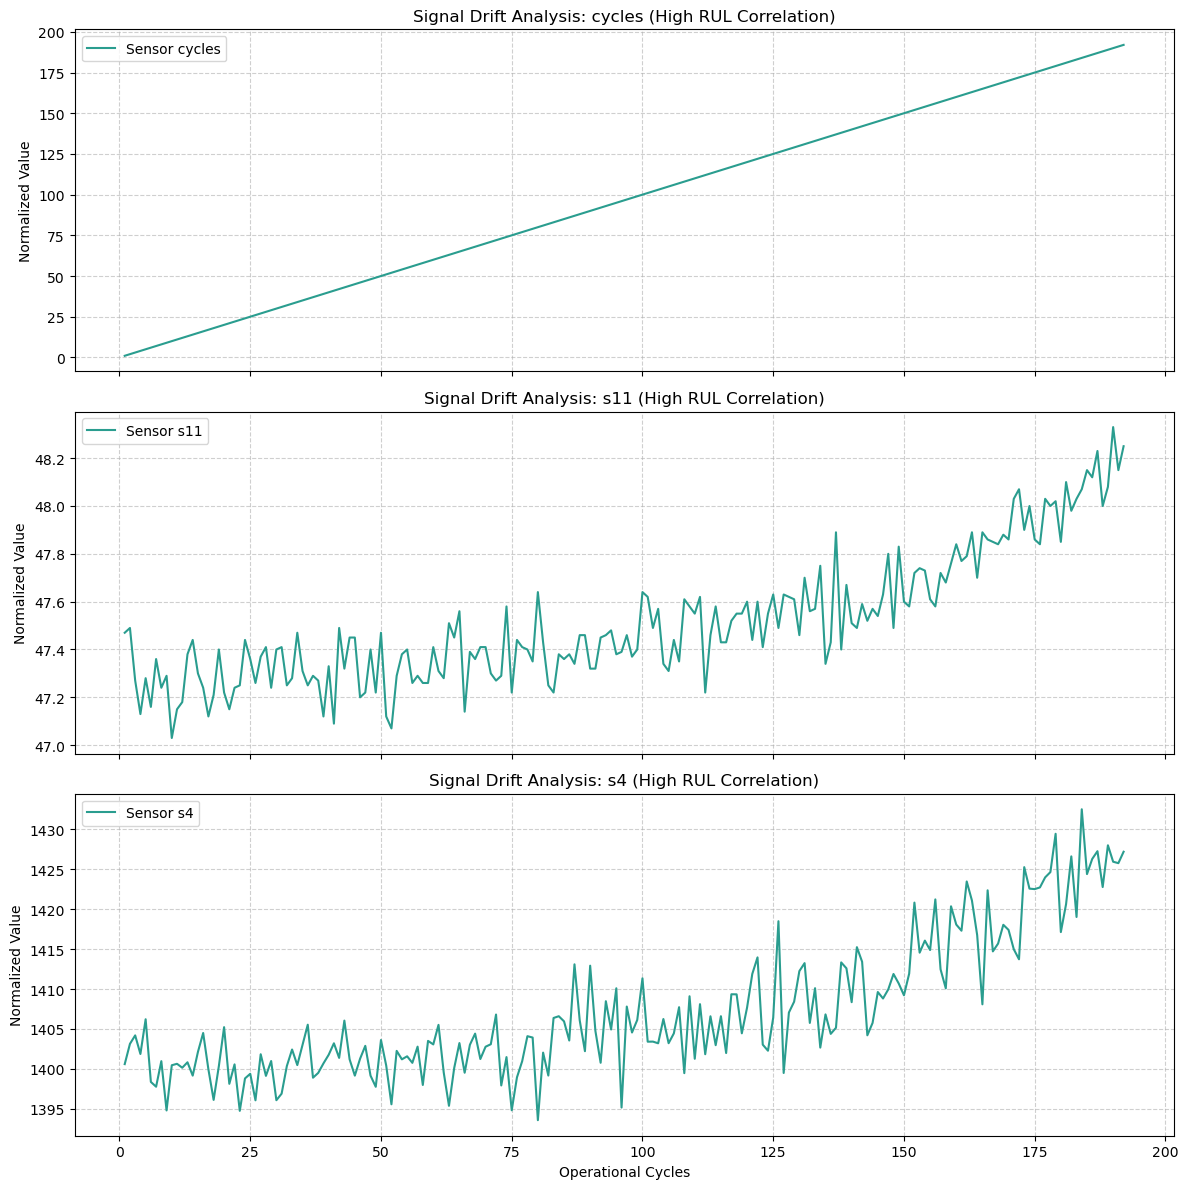

In [ ]:
# --- Advanced Signal Analysis: Identifying Degradation Patterns ---

def plot_degradation_indicators(df, unit_id, sensors):
    """
    Analyzes and visualizes the drift of selected sensors for a specific unit.
    Sensors are chosen based on their high correlation with RUL (target variable).
    """
    unit_data = df[df['unit'] == unit_id]
    fig, axes = plt.subplots(len(sensors), 1, figsize=(12, 4 * len(sensors)), sharex=True)
    
    for i, sensor in enumerate(sensors):
        axes[i].plot(unit_data['cycles'], unit_data[sensor], label=f'Sensor {sensor}', color='#2a9d8f')
        axes[i].set_title(f'Signal Drift Analysis: {sensor} (High RUL Correlation)', fontsize=12)
        axes[i].set_ylabel('Normalized Value')
        axes[i].grid(True, linestyle='--', alpha=0.6)
        axes[i].legend(loc='upper left')
        
    plt.xlabel('Operational Cycles')
    plt.tight_layout()
    plt.show()

# Selecting top sensors based on absolute correlation with RUL, 
# excluding the RUL column itself.
top_sensors = correlations.drop('RUL').abs().nlargest(3).index.tolist()
plot_degradation_indicators(df, 1, top_sensors)

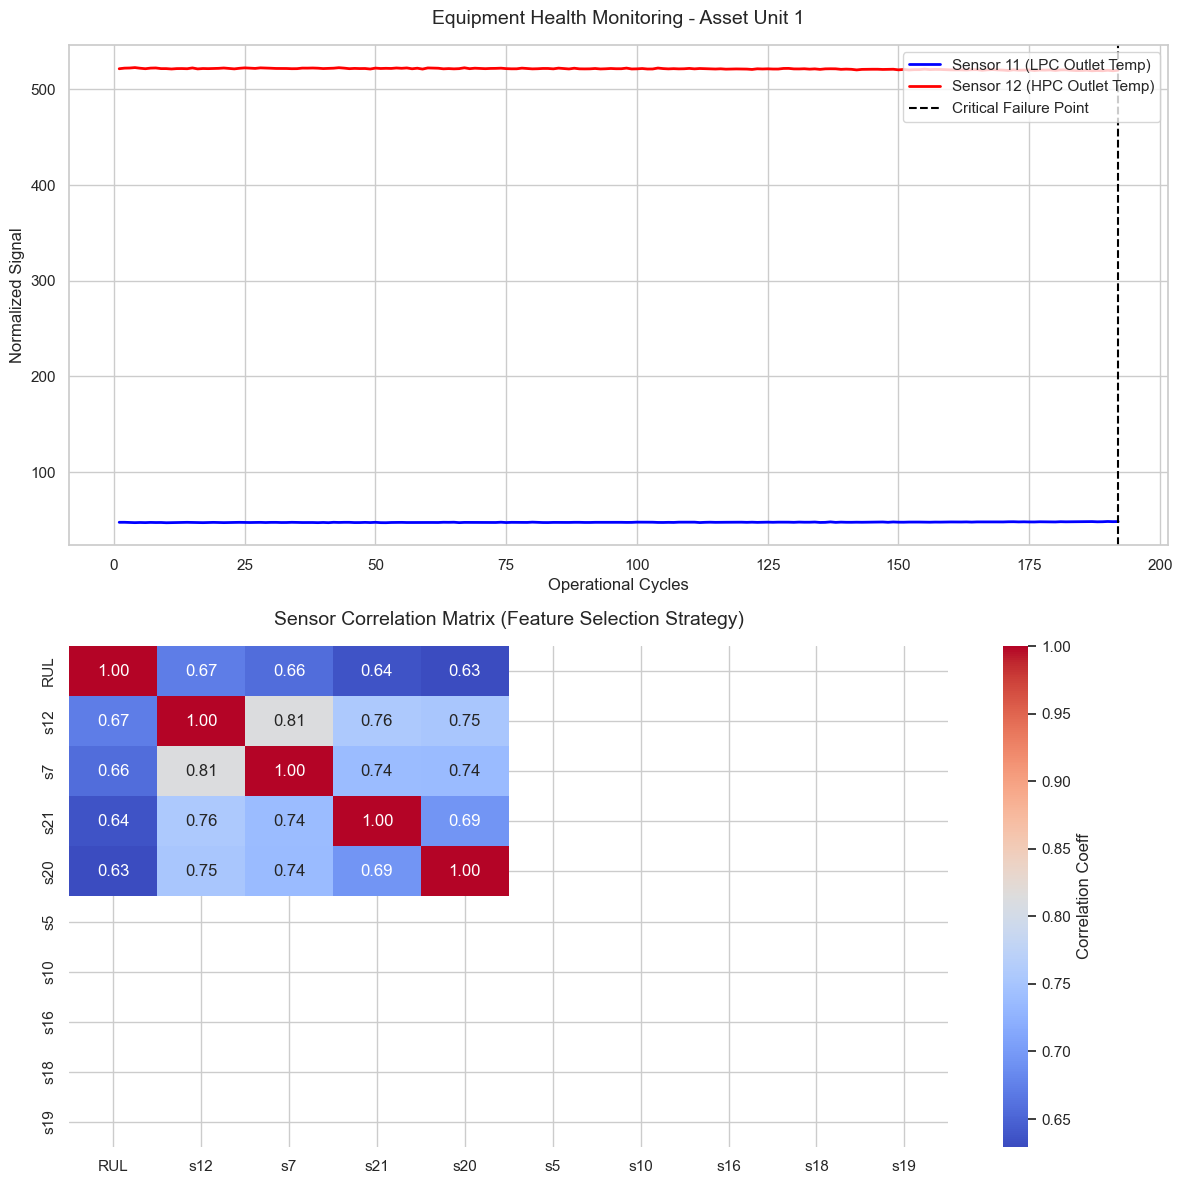


[INFO] Data processing and visualization complete.


In [5]:
# Set the aesthetic style of the plots
sns.set_theme(style="whitegrid")

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 12))

# Plot A: Time-Series Sensor Drift (Unit 1 Case Study)
sample_unit = 1
unit_data = df[df['unit'] == sample_unit]

ax1.plot(unit_data['cycles'], unit_data['s11'], label='Sensor 11 (LPC Outlet Temp)', color='blue', lw=2)
ax1.plot(unit_data['cycles'], unit_data['s12'], label='Sensor 12 (HPC Outlet Temp)', color='red', lw=2)
ax1.axvline(x=unit_data['cycles'].max(), color='black', linestyle='--', label='Critical Failure Point')

ax1.set_title(f'Equipment Health Monitoring - Asset Unit {sample_unit}', fontsize=14, pad=15)
ax1.set_xlabel('Operational Cycles')
ax1.set_ylabel('Normalized Signal')
ax1.legend(loc='upper right')

# Plot B: Feature Interaction Heatmap
top_features = correlations.index[:5].tolist() + correlations.index[-5:].tolist()
sns.heatmap(df[top_features].corr(), annot=True, cmap='coolwarm', ax=ax2, fmt=".2f", cbar_kws={'label': 'Correlation Coeff'})

ax2.set_title('Sensor Correlation Matrix (Feature Selection Strategy)', fontsize=14, pad=15)

plt.tight_layout()
plt.show()

print("\n[INFO] Data processing and visualization complete.")